# Making MTM Savings Defensible
### Regression to the mean, engagement selection, and a matched difference-in-differences estimator

**Author:** Faridoon Farahi  |  **Data:** fully simulated (no PHI, no client data)

Medication therapy management (MTM) and medication-optimization programs usually report outcomes the same way:
*"$X saved per engaged member per year"* or *"Y% reduction in total cost of care among members who received interventions."*

Those are **pre/post comparisons on the engaged, high-risk subgroup**. When a contract moves to value-based terms, the client's actuary asks two questions:

1. **Regression to the mean.** Members were selected *because* they were expensive last year. Some of that was bad luck, and bad luck doesn't repeat. How much of the "savings" would have happened with no program at all?
2. **Engagement selection.** Members who pick up the phone differ from those who don't. Is the engaged group's improvement caused by the program, or by whatever made them engage?

This notebook shows, on simulated Medicare-like data, that a naive pre/post produces large "savings" **even when the program does nothing**, and that a **propensity-matched difference-in-differences (DiD)** design recovers the true effect. It ends with the checklist I would want in hand before putting a savings number in front of a plan's finance team.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from mtm_eval import (simulate_population, naive_pre_post, propensity_match,
                      balance_table, did_estimate, dollar_savings_pmpy, monte_carlo, COVARIATES)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.float_format = "{:,.2f}".format

## 1. Simulated plan population

80,000 members, two 12-month periods. Each member has a **persistent** risk (age, chronic conditions, medication count, dual eligibility, frailty) plus a **transient** shock each year. Annual cost is log-normal, which is what real claims look like: a long right tail driven by hospitalizations.

The plan targets the **top 10% by a pre-period risk score** (built mostly from last year's cost — a very common rule). Among targeted members, engagement is not random: members on more medications, less frail, and non-dual are more likely to engage.

We start with a world where the program has **zero true effect**. Any "savings" we find are an artifact.

In [2]:
df0 = simulate_population(true_effect=0.0)
df0[["age","n_chronic","n_meds","dual_eligible","cost_pre","cost_post"]].describe().T[["mean","50%","std"]]

,mean,50%,std
age,72.83,72.00,6.72
n_chronic,2.20,2.00,1.48
n_meds,7.39,7.00,3.43
dual_eligible,0.25,0.00,0.43
cost_pre,"22,290.31","14,598.48","26,583.12"
cost_post,"22,360.47","14,670.44","26,692.69"


In [3]:
print(f"Targeted: {df0.targeted.sum():,}   Engaged: {df0.engaged.sum():,}   "
      f"Engagement rate among targeted: {df0.engaged.sum()/df0.targeted.sum():.0%}")

Targeted: 8,000   Engaged: 4,087   Engagement rate among targeted: 51%


## 2. The naive estimator: pre/post on engaged members

This is the calculation behind "savings per engaged member per year".

In [4]:
naive0 = naive_pre_post(df0)
print(f"Engaged members:        {naive0['n_engaged']:,}")
print(f"Mean cost, pre period:  ${naive0['mean_cost_pre']:,.0f}")
print(f"Mean cost, post period: ${naive0['mean_cost_post']:,.0f}")
print(f"'Savings' PMPY:         ${naive0['savings_pmpy']:,.0f}   ({naive0['pct_change']:+.1%})")
print("\nTrue program effect in this simulation: 0%")

Engaged members:        4,087
Mean cost, pre period:  $79,456
Mean cost, post period: $51,746
'Savings' PMPY:         $27,710   (-34.9%)

True program effect in this simulation: 0%


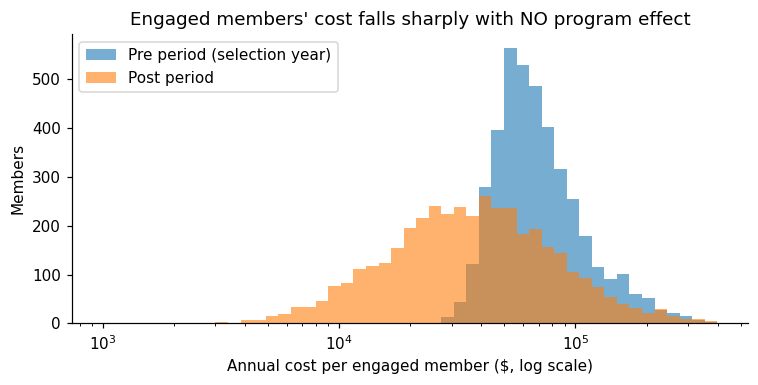

In [5]:
fig, ax = plt.subplots(figsize=(7,3.6))
e = df0[df0.engaged==1]
bins = np.logspace(3, 5.6, 50)
ax.hist(e.cost_pre, bins=bins, alpha=.6, label="Pre period (selection year)")
ax.hist(e.cost_post, bins=bins, alpha=.6, label="Post period")
ax.set_xscale("log"); ax.set_xlabel("Annual cost per engaged member ($, log scale)"); ax.set_ylabel("Members")
ax.set_title("Engaged members' cost falls sharply with NO program effect")
ax.legend(); plt.tight_layout()

A **35% cost reduction and roughly $28K of "savings" per engaged member** — with a program that did nothing. This is regression to the mean: members were selected on a noisy high value, and the noise didn't repeat.

The same mechanism produces the hospitalization and ED-visit reductions programs report, because those events are exactly what made the pre-period cost spike.

## 3. A defensible design: propensity-matched difference-in-differences

**Comparison group.** Members who did *not* engage, matched 1:1 to engaged members on the propensity to engage. The propensity model includes **pre-period cost**, so each matched control also "looked expensive last year" — that neutralises regression to the mean. The other covariates address engagement selection.

**Estimator.** Difference-in-differences on log cost: (engaged post − engaged pre) − (control post − control pre). With two periods this is the same as regressing each member's change in log cost on treatment. Standard errors clustered by matched pair.

First, the balance check an actuary or HEOR reviewer will ask for: standardised mean differences after matching should be within ±0.10.

In [6]:
m0 = propensity_match(df0, COVARIATES)
bal = balance_table(m0, COVARIATES)
bal.style.format({"treated_mean":"{:,.2f}","control_mean":"{:,.2f}","smd":"{:+.3f}"}) \
   .map(lambda v: "color:red" if abs(v)>0.1 else "color:green", subset=["smd"])

,covariate,treated_mean,control_mean,smd
0,age,74.69,74.63,+0.009
1,n_chronic,4.20,4.12,+0.053
2,n_meds,11.74,11.50,+0.070
3,dual_eligible,0.34,0.35,-0.032
4,frailty,0.39,0.49,-0.104
5,cost_pre,"79,456.44","81,470.08",-0.039


In [7]:
did0 = did_estimate(m0)
print(f"Matched pairs:      {did0['n_pairs']:,}")
print(f"DiD effect on cost: {did0['did_pct']:+.1%}   95% CI [{did0['ci_pct'][0]:+.1%}, {did0['ci_pct'][1]:+.1%}]")
print(f"Savings PMPY:       ${dollar_savings_pmpy(m0, did0['did_pct']):,.0f}")
print("\nTrue effect: 0%  ->  the matched DiD correctly finds nothing.")

Matched pairs:      4,087
DiD effect on cost: -2.3%   95% CI [-5.5%, +1.0%]
Savings PMPY:       $1,230

True effect: 0%  ->  the matched DiD correctly finds nothing.


## 4. Now give the program a real effect

Same population, but engaged members' post-period cost is **10% lower** because of the program. Does each method find it?

In [8]:
df1 = simulate_population(true_effect=-0.10)
naive1 = naive_pre_post(df1)
m1 = propensity_match(df1, COVARIATES)
did1 = did_estimate(m1)

summary = pd.DataFrame({
    "True effect": ["0%", "-10%"],
    "Naive pre/post (engaged)": [f"{naive0['pct_change']:+.1%}  (${naive0['savings_pmpy']:,.0f})",
                                 f"{naive1['pct_change']:+.1%}  (${naive1['savings_pmpy']:,.0f})"],
    "Matched DiD": [f"{did0['did_pct']:+.1%}  (${dollar_savings_pmpy(m0, did0['did_pct']):,.0f})",
                    f"{did1['did_pct']:+.1%}  (${dollar_savings_pmpy(m1, did1['did_pct']):,.0f})"],
}).set_index("True effect")
summary

,Naive pre/post (engaged),Matched DiD
True effect,,
0%,"-34.9% ($27,710)","-2.3% ($1,230)"
-10%,"-41.4% ($32,885)","-12.1% ($6,496)"


The naive number barely moves between "no effect" and "real 10% effect" — it is dominated by selection, not by the program. The matched DiD lands on the truth in both cases.

**The dollar gap matters for contracts.** In the real-effect world, the naive method claims ~$33K PMPY; the defensible method finds ~$6.5K PMPY. The second number is smaller, but it is the one that survives an audit — and it is the one you can put a shared-savings percentage on.

## 5. Is that luck? Repeat it 30 times

Naive:  mean -41.5%   Matched DiD: mean -8.6%   (truth -10%)


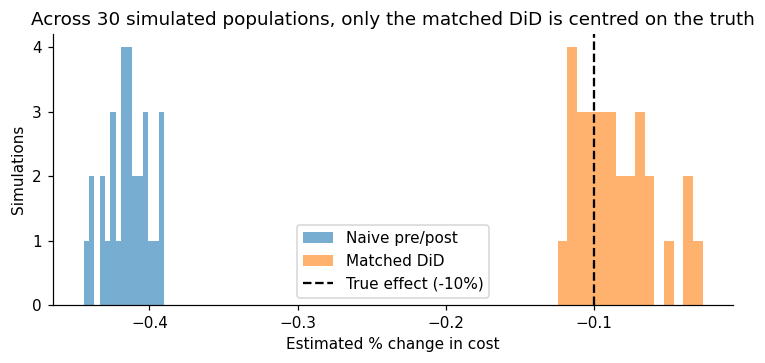

In [9]:
mc = monte_carlo(true_effect=-0.10, covariates=COVARIATES, n_sims=30, n=30_000)
fig, ax = plt.subplots(figsize=(7,3.4))
ax.hist(mc.naive_pct, bins=15, alpha=.6, label="Naive pre/post")
ax.hist(mc.did_pct, bins=15, alpha=.6, label="Matched DiD")
ax.axvline(-0.10, color="k", ls="--", label="True effect (-10%)")
ax.set_xlabel("Estimated % change in cost"); ax.set_ylabel("Simulations")
ax.set_title("Across 30 simulated populations, only the matched DiD is centred on the truth")
ax.legend(); plt.tight_layout()
print(f"Naive:  mean {mc.naive_pct.mean():+.1%}   Matched DiD: mean {mc.did_pct.mean():+.1%}   (truth -10%)")

## 6. What I would want in hand before reporting a savings number

1. **A comparison group that was selected the same way.** Matched non-engaged members from the same targeting rule, or a randomised/staggered rollout if the client will allow it. Never "engaged vs. everyone else."
2. **Balance diagnostics.** Standardised mean differences on risk score, prior cost, prior utilisation, chronic burden, dual status. All within ±0.10, shown in the deliverable.
3. **Difference-in-differences, not pre/post.** Report the DiD point estimate with a confidence interval, on log cost (heavy tails) and separately on the utilisation counts the client cares about (admits, ED visits).
4. **A placebo test.** Run the same design on a pre-program year pair. If it "finds savings" where there was no program, the design is broken.
5. **Sensitivity to the caliper and covariate set**, and an intention-to-treat version (all *targeted* members, not just engaged) — that's the number the plan actually pays for.
6. **A plain-English one-pager for the client's finance team** that leads with the conservative estimate.

This is the discipline I applied for four years at Kaiser Permanente measuring operational program impact for finance and operations leaders, and it is the same discipline that lets a medication-optimization vendor sign value-based contracts with confidence.
